In [2]:
# Data Manipulation

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings

import warnings
warnings.filterwarnings("ignore")

# Plot settings

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 12

# Display all columns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Matplotlib is building the font cache; this may take a moment.


In [3]:
# Load datasets
demand_df = pd.read_csv("../data/raw/demand.csv")
promo_df = pd.read_csv("../data/raw/promotions.csv")

In [4]:
print("Demand Dataset Shape:", demand_df.shape)
print("Promotion Dataset Shape:", promo_df.shape)

Demand Dataset Shape: (9855, 4)
Promotion Dataset Shape: (15, 4)


In [5]:
demand_df.head()

,date,demand,sku,supermarket
0,1/1/2019,93.0,Organic Milk,FreshMart
1,1/2/2019,93.0,Organic Milk,FreshMart
2,1/3/2019,94.0,Organic Milk,FreshMart
3,1/4/2019,95.0,Organic Milk,FreshMart
4,1/5/2019,92.0,Organic Milk,FreshMart


In [6]:
promo_df.head()

,Unnamed: 0,promotion_date,sku,supermarket
0,0,9/26/2020,Organic Milk,DailyNeeds
1,1,9/18/2019,Organic Milk,DailyNeeds
2,2,9/28/2021,Organic Milk,DailyNeeds
3,3,2/11/2021,Organic Milk,DailyNeeds
4,0,10/3/2021,Organic Milk,GreenBasket


In [7]:
demand_df.sample(5)

,date,demand,sku,supermarket
6451,9/3/2021,97.0,Whole Wheat Bread,GreenBasket
5594,4/30/2019,90.0,Whole Wheat Bread,GreenBasket
1778,11/14/2020,NaN,Organic Milk,DailyNeeds
4537,6/7/2019,55.0,Whole Wheat Bread,DailyNeeds
1292,7/17/2019,NaN,Organic Milk,DailyNeeds


In [8]:
demand_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9855 entries, 0 to 9854
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         9855 non-null   str    
 1   demand       8738 non-null   float64
 2   sku          9855 non-null   str    
 3   supermarket  9855 non-null   str    
dtypes: float64(1), str(3)
memory usage: 308.1 KB


In [9]:
promo_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0      15 non-null     int64
 1   promotion_date  15 non-null     str  
 2   sku             15 non-null     str  
 3   supermarket     15 non-null     str  
dtypes: int64(1), str(3)
memory usage: 612.0 bytes


In [10]:
demand_df.describe()

,demand
count,8738.000000
mean,74.240764
std,24.354299
min,10.000000
25%,57.000000
50%,70.000000
75%,93.000000
max,485.000000


In [21]:
promo_df.describe()

,Unnamed: 0,promotion_date
count,15.000000,15
mean,0.933333,2020-07-09 04:48:00
min,0.000000,2019-01-08 00:00:00
25%,0.000000,2019-08-27 12:00:00
50%,1.000000,2020-09-26 00:00:00
75%,1.500000,2021-06-01 00:00:00
max,3.000000,2021-10-03 00:00:00
std,1.099784,NaN


In [11]:
demand_df.describe(include="object")

,date,sku,supermarket
count,9855,9855,9855
unique,1095,3,3
top,1/1/2019,Organic Milk,FreshMart
freq,9,3285,3285


In [ ]:
missing = demand_df.isnull().sum()

missing

date              0
demand         1117
sku               0
supermarket       0
dtype: int64

In [20]:
missing = promo_df.isnull().sum()

missing

Unnamed: 0        0
promotion_date    0
sku               0
supermarket       0
dtype: int64

In [13]:
missing_percent = (
    demand_df.isnull().mean()*100
).sort_values(ascending=False)

missing_percent

demand         11.334348
date            0.000000
sku             0.000000
supermarket     0.000000
dtype: float64

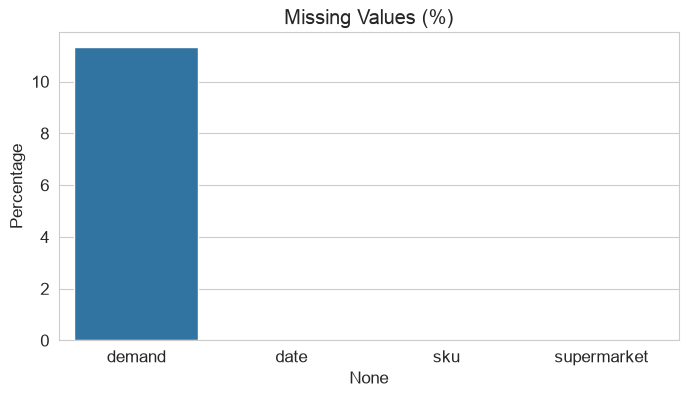

In [36]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=missing_percent.index,
    y=missing_percent.values
)

plt.title("Missing Values (%)")
plt.ylabel("Percentage")

plt.show()

In [38]:
plt.savefig("../outputs/figures/missing_values.png")

<Figure size 1200x600 with 0 Axes>

In [17]:
duplicates = demand_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [22]:
duplicates = promo_df.duplicated().sum()
print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [18]:
demand_df["date"] = pd.to_datetime(demand_df["date"])
promo_df["promotion_date"] = pd.to_datetime(
    promo_df["promotion_date"]
)

In [23]:
demand_start = demand_df["date"].min()
demand_end = demand_df["date"].max()

print("Demand Start:", demand_start)
print("Demand End:", demand_end)

Demand Start: 2019-01-01 00:00:00
Demand End: 2021-12-30 00:00:00


In [24]:
outside_promotions = promo_df[
    (promo_df["promotion_date"] < demand_start) |
    (promo_df["promotion_date"] > demand_end)
]

outside_promotions

,Unnamed: 0,promotion_date,sku,supermarket


In [25]:
promo_df["supermarket"].value_counts()

supermarket
FreshMart      6
DailyNeeds     5
GreenBasket    4
Name: count, dtype: int64

In [26]:
promo_df["sku"].value_counts()

sku
Whole Wheat Bread    7
Organic Milk         5
Free Range Eggs      3
Name: count, dtype: int64

In [27]:
promotion_summary = pd.crosstab(
    promo_df["supermarket"],
    promo_df["sku"]
)

promotion_summary

sku,Free Range Eggs,Organic Milk,Whole Wheat Bread
supermarket,,,
DailyNeeds,0,4,1
FreshMart,2,0,4
GreenBasket,1,1,2


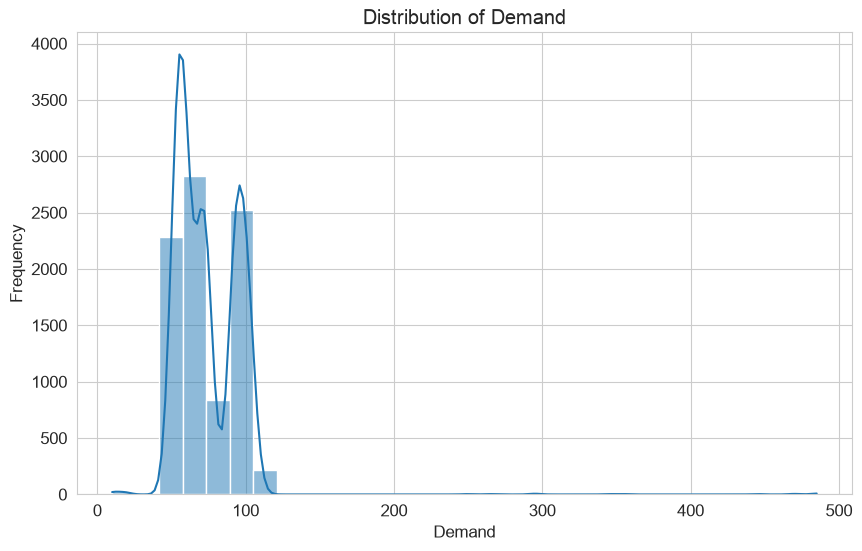

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=demand_df,
    x="demand",
    bins=30,
    kde=True
)

plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")

plt.savefig("../outputs/figures/demand_distribution.png")
plt.show()

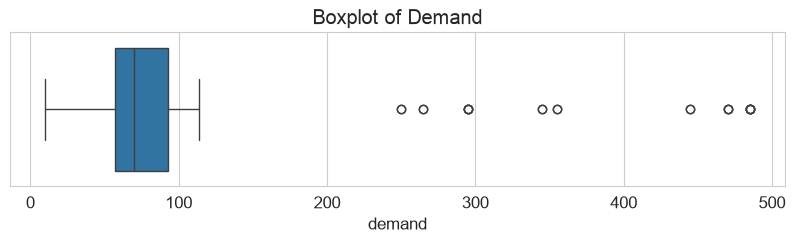

In [29]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=demand_df["demand"]
)

plt.title("Boxplot of Demand")

plt.savefig("../outputs/figures/demand_boxplot.png")
plt.show()

In [30]:
print("Mean:", demand_df["demand"].mean())
print("Median:", demand_df["demand"].median())
print("Standard Deviation:", demand_df["demand"].std())
print("Skewness:", demand_df["demand"].skew())
print("Kurtosis:", demand_df["demand"].kurt())

Mean: 74.24076447699701
Median: 70.0
Standard Deviation: 24.354299484161555
Skewness: 6.296279924743094
Kurtosis: 92.32340333304998


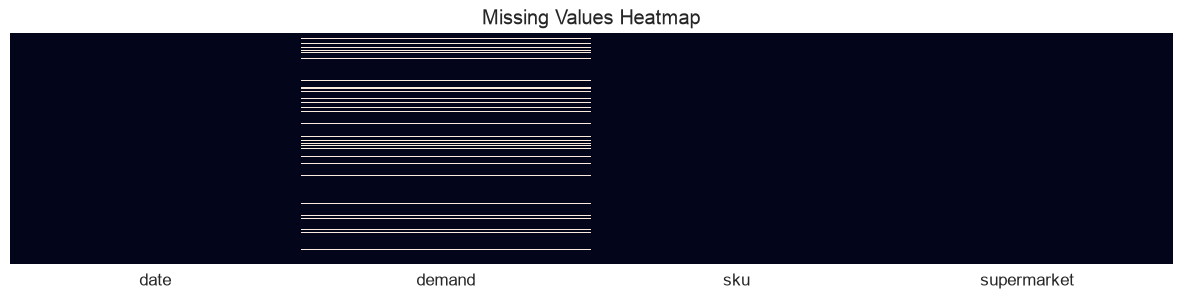

In [31]:
plt.figure(figsize=(15,3))

sns.heatmap(
    demand_df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.savefig("../outputs/figures/missing_values_heatmap.png")
plt.show()

In [32]:
missing_supermarket = (
    demand_df.groupby("supermarket")["demand"]
    .apply(lambda x: x.isnull().sum())
    .sort_values(ascending=False)
)

missing_supermarket

supermarket
GreenBasket    401
FreshMart      393
DailyNeeds     323
Name: demand, dtype: int64

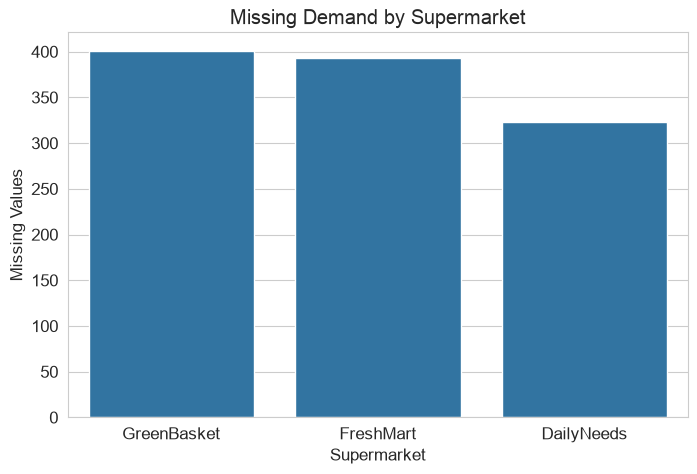

In [33]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_supermarket.index,
    y=missing_supermarket.values
)

plt.title("Missing Demand by Supermarket")
plt.xlabel("Supermarket")
plt.ylabel("Missing Values")

plt.savefig("../outputs/figures/missing_by_supermarket.png")
plt.show()

In [34]:
missing_sku = (
    demand_df.groupby("sku")["demand"]
    .apply(lambda x: x.isnull().sum())
    .sort_values(ascending=False)
)

missing_sku

sku
Organic Milk         391
Free Range Eggs      368
Whole Wheat Bread    358
Name: demand, dtype: int64

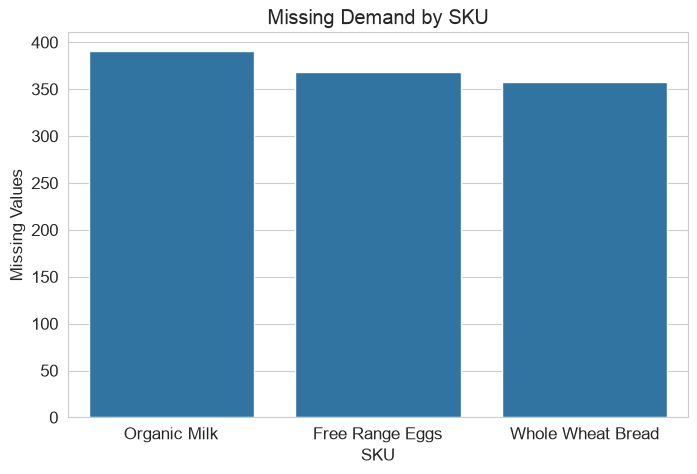

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_sku.index,
    y=missing_sku.values
)

plt.title("Missing Demand by SKU")
plt.xlabel("SKU")
plt.ylabel("Missing Values")

plt.savefig("../outputs/figures/missing_by_sku.png")
plt.show()

In [39]:
# Display observations with unusually high demand
high_demand = demand_df[demand_df["demand"] > 200].sort_values("demand", ascending=False)

high_demand

,date,demand,sku,supermarket
1237,2019-05-23,485.0,Organic Milk,DailyNeeds
1475,2020-01-16,485.0,Organic Milk,DailyNeeds
1522,2020-03-03,485.0,Organic Milk,DailyNeeds
1838,2021-01-13,485.0,Organic Milk,DailyNeeds
2165,2021-12-06,485.0,Organic Milk,DailyNeeds
29,2019-01-30,470.0,Organic Milk,FreshMart
659,2020-10-21,470.0,Organic Milk,FreshMart
819,2021-03-30,470.0,Organic Milk,FreshMart
6557,2021-12-18,445.0,Whole Wheat Bread,GreenBasket
6102,2020-09-19,445.0,Whole Wheat Bread,GreenBasket


In [40]:
# Aggregate demand across all supermarkets and SKUs
daily_demand = (
    demand_df
    .groupby("date")["demand"]
    .sum()
    .reset_index()
)

daily_demand.head()

,date,demand
0,2019-01-01,622.0
1,2019-01-02,481.0
2,2019-01-03,579.0
3,2019-01-04,571.0
4,2019-01-05,534.0


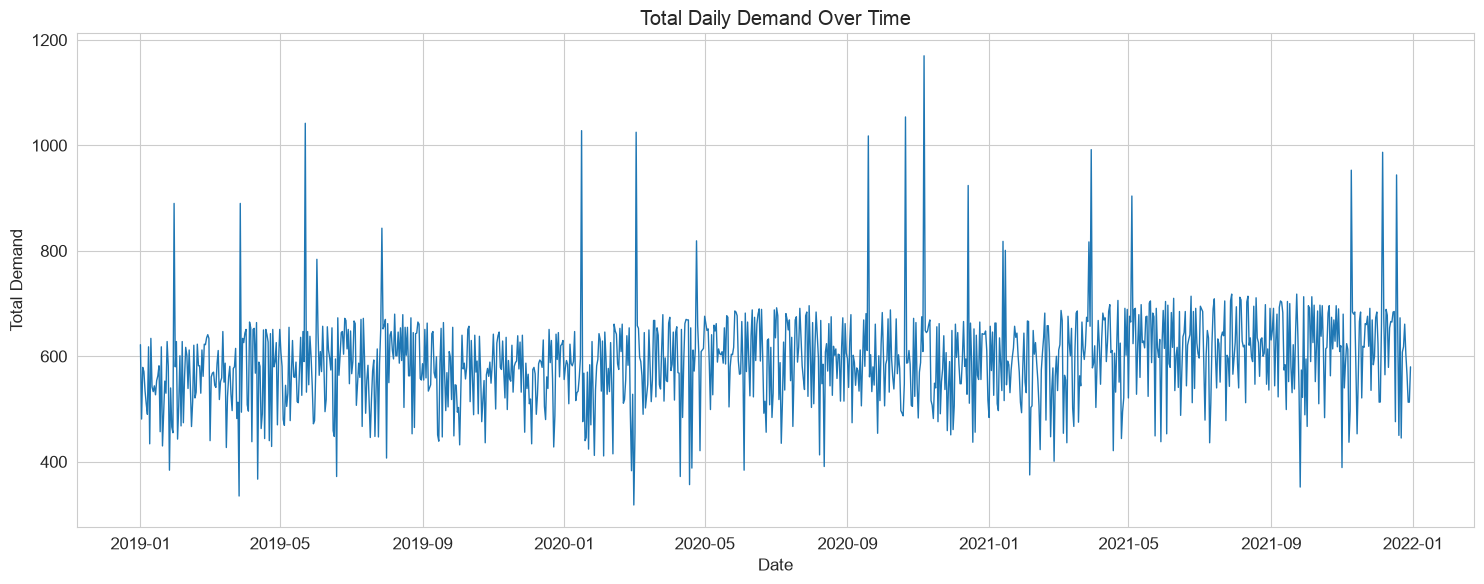

In [41]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand"],
    linewidth=1
)

plt.title("Total Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Demand")

plt.tight_layout()
plt.savefig("../outputs/figures/daily_demand_trend.png")
plt.show()

In [42]:
daily_demand["rolling_30"] = (
    daily_demand["demand"]
    .rolling(window=30)
    .mean()
)

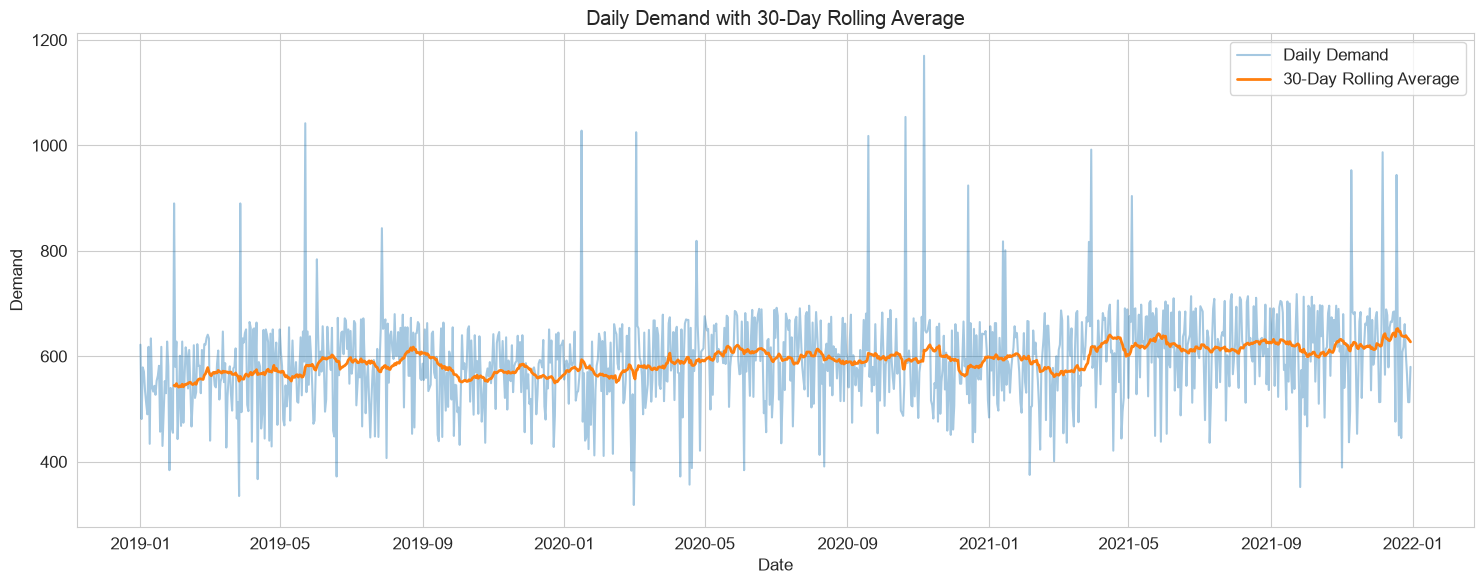

In [43]:
plt.figure(figsize=(15,6))

plt.plot(
    daily_demand["date"],
    daily_demand["demand"],
    alpha=0.4,
    label="Daily Demand"
)

plt.plot(
    daily_demand["date"],
    daily_demand["rolling_30"],
    linewidth=2,
    label="30-Day Rolling Average"
)

plt.title("Daily Demand with 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/daily_trend_rolling_average.png")
plt.show()

In [45]:
monthly_demand = (
    demand_df
    .set_index("date")
    .resample("ME")["demand"]
    .sum()
    .reset_index()
)

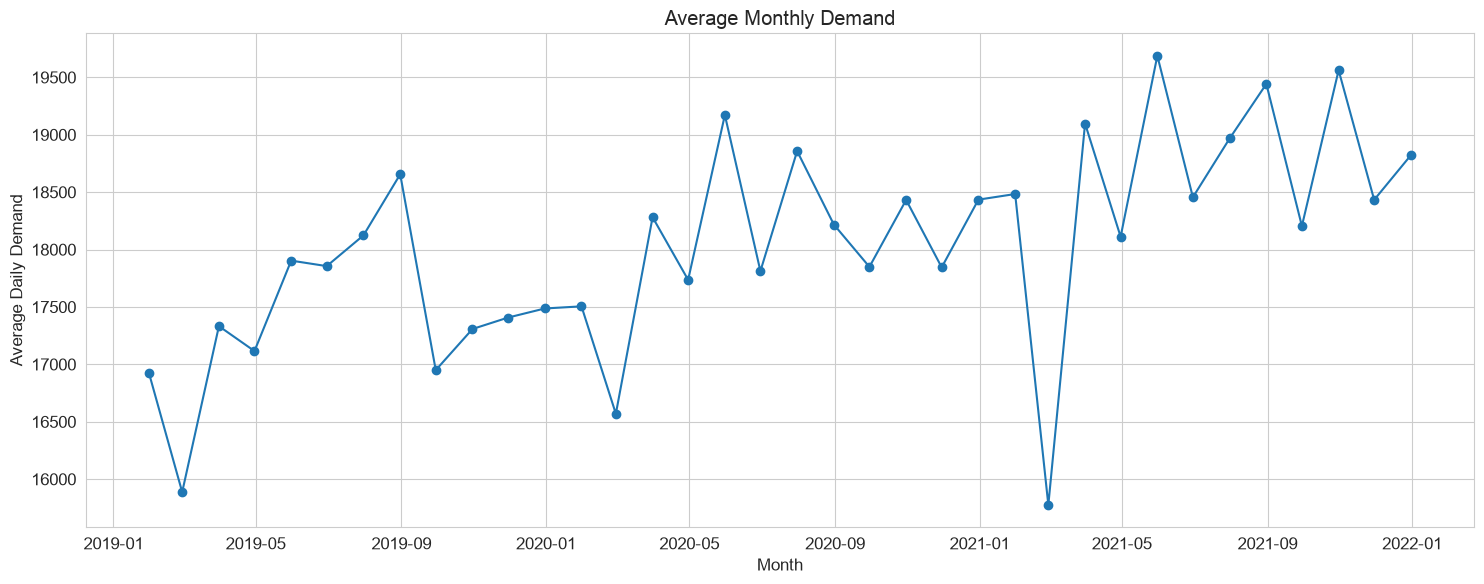

In [47]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_demand["date"],
    monthly_demand["demand"],
    marker="o"
)

plt.title("Average Monthly Demand")
plt.xlabel("Month")
plt.ylabel("Average Daily Demand")

plt.tight_layout()
plt.savefig("../outputs/figures/monthly_demand_trend.png")
plt.show()

In [48]:
sku_daily = (
    demand_df
    .groupby(["date", "sku"])["demand"]
    .sum()
    .reset_index()
)

sku_daily.head()

,date,sku,demand
0,2019-01-01,Free Range Eggs,192.0
1,2019-01-01,Organic Milk,237.0
2,2019-01-01,Whole Wheat Bread,193.0
3,2019-01-02,Free Range Eggs,138.0
4,2019-01-02,Organic Milk,236.0


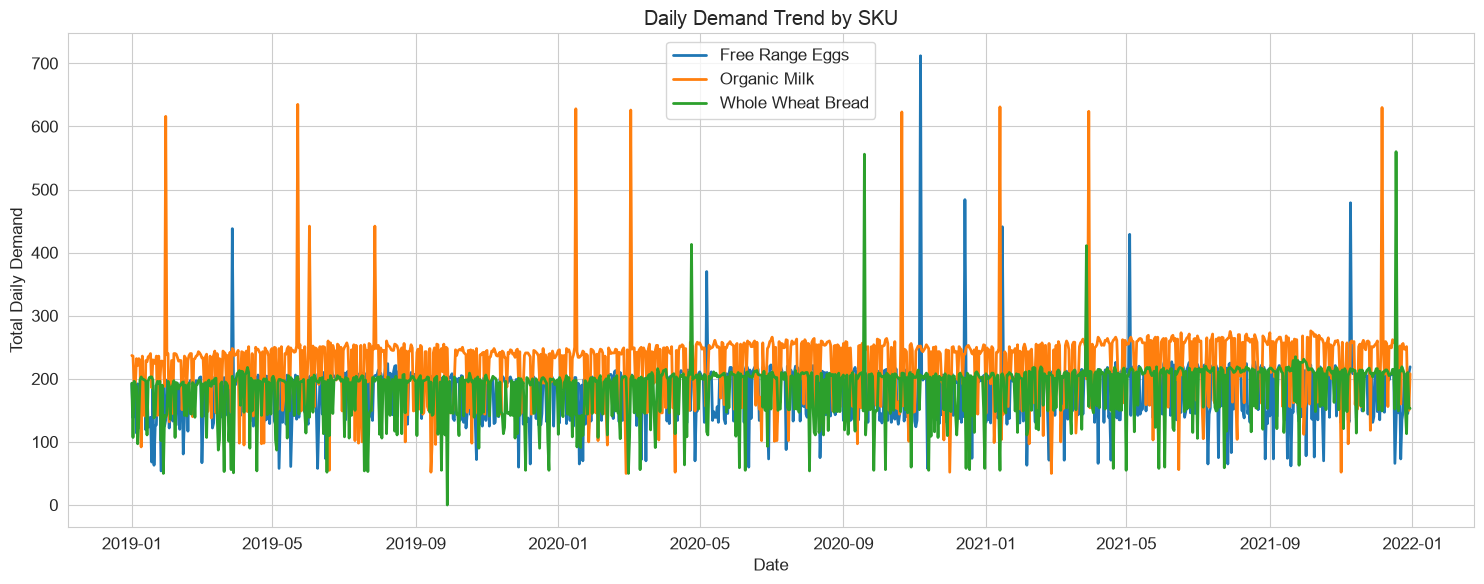

In [49]:
plt.figure(figsize=(15,6))

for sku in sku_daily["sku"].unique():
    temp = sku_daily[sku_daily["sku"] == sku]

    plt.plot(
        temp["date"],
        temp["demand"],
        label=sku,
        linewidth=2
    )

plt.title("Daily Demand Trend by SKU")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/demand_by_sku.png")
plt.show()

In [50]:
market_daily = (
    demand_df
    .groupby(["date", "supermarket"])["demand"]
    .sum()
    .reset_index()
)

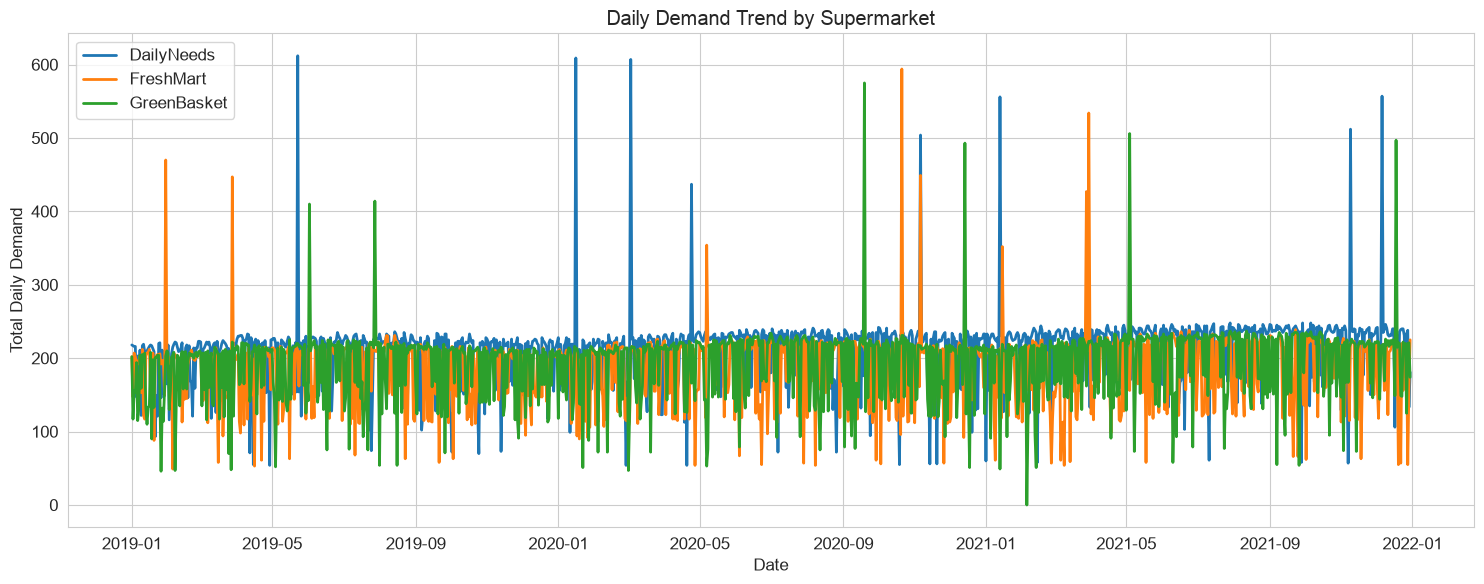

In [51]:
plt.figure(figsize=(15,6))

for market in market_daily["supermarket"].unique():

    temp = market_daily[
        market_daily["supermarket"] == market
    ]

    plt.plot(
        temp["date"],
        temp["demand"],
        label=market,
        linewidth=2
    )

plt.title("Daily Demand Trend by Supermarket")
plt.xlabel("Date")
plt.ylabel("Total Daily Demand")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/demand_by_supermarket.png")
plt.show()

In [52]:
sku_daily["rolling_30"] = (
    sku_daily
    .groupby("sku")["demand"]
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

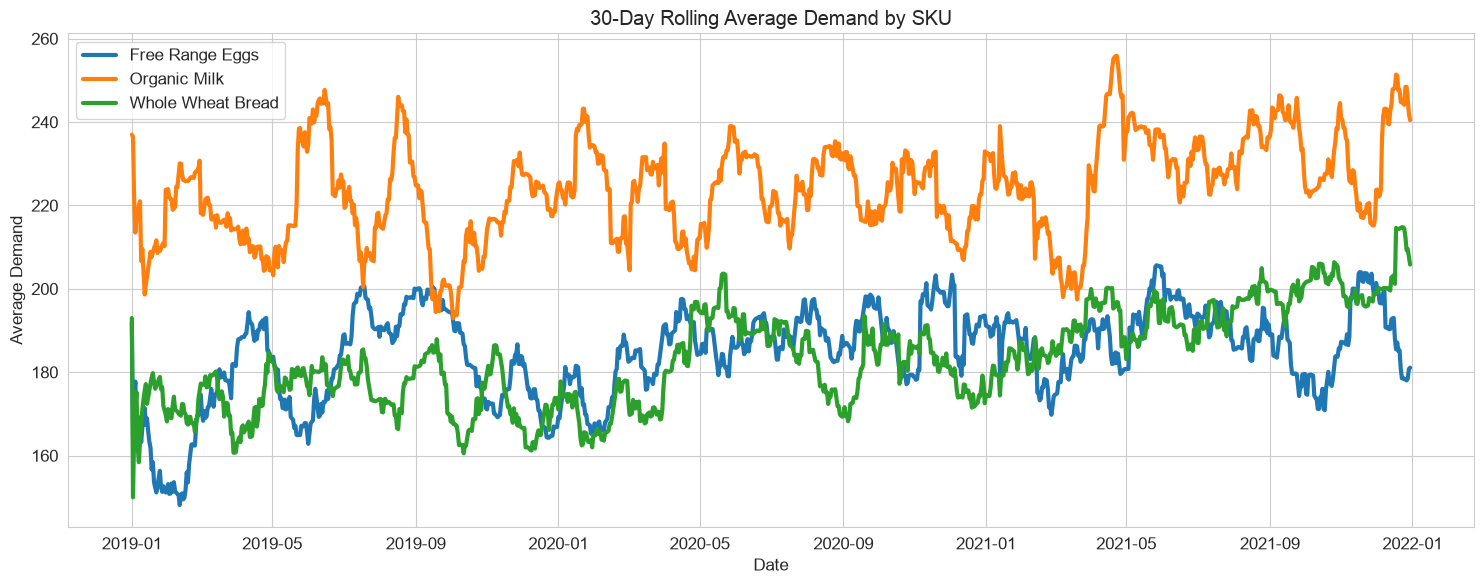

In [53]:
plt.figure(figsize=(15,6))

for sku in sku_daily["sku"].unique():

    temp = sku_daily[
        sku_daily["sku"] == sku
    ]

    plt.plot(
        temp["date"],
        temp["rolling_30"],
        linewidth=3,
        label=sku
    )

plt.title("30-Day Rolling Average Demand by SKU")
plt.xlabel("Date")
plt.ylabel("Average Demand")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/rolling_demand_by_sku.png")
plt.show()

In [54]:
market_daily["rolling_30"] = (
    market_daily
    .groupby("supermarket")["demand"]
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)

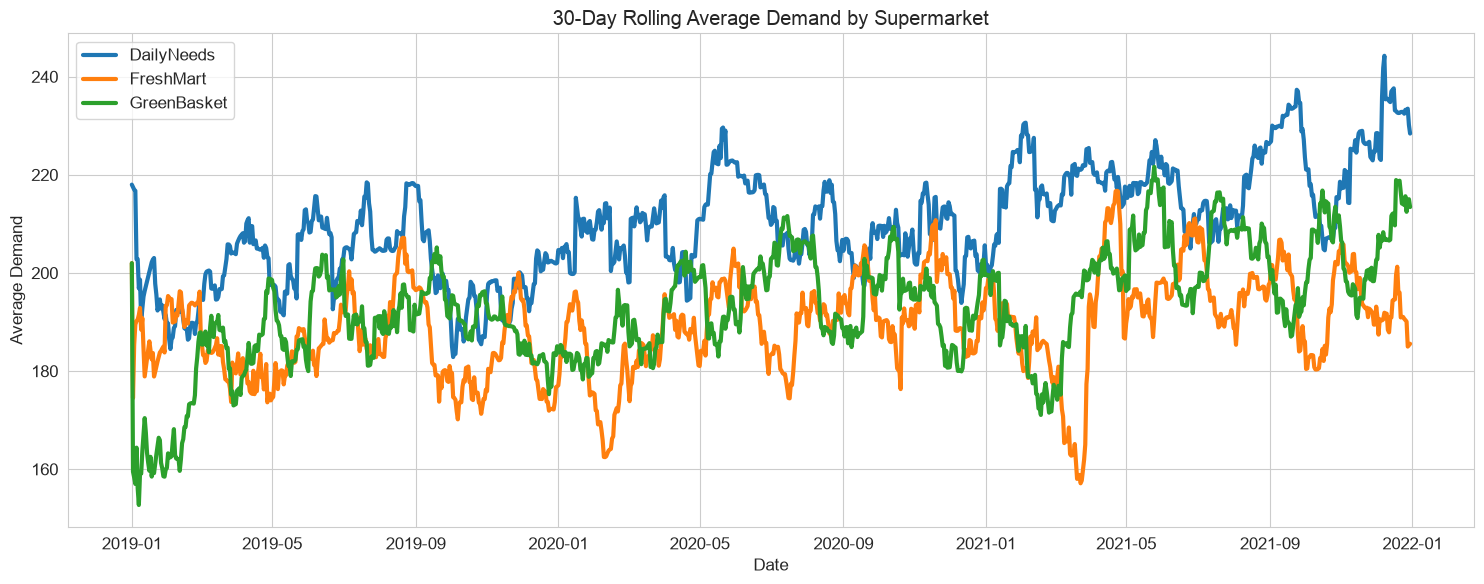

In [55]:
plt.figure(figsize=(15,6))

for market in market_daily["supermarket"].unique():

    temp = market_daily[
        market_daily["supermarket"] == market
    ]

    plt.plot(
        temp["date"],
        temp["rolling_30"],
        linewidth=3,
        label=market
    )

plt.title("30-Day Rolling Average Demand by Supermarket")
plt.xlabel("Date")
plt.ylabel("Average Demand")
plt.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/rolling_demand_by_supermarket.png")
plt.show()

In [56]:
# Create day of week feature
demand_df["day_of_week"] = demand_df["date"].dt.day_name()

In [57]:
weekday_demand = (
    demand_df
    .groupby("day_of_week")["demand"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

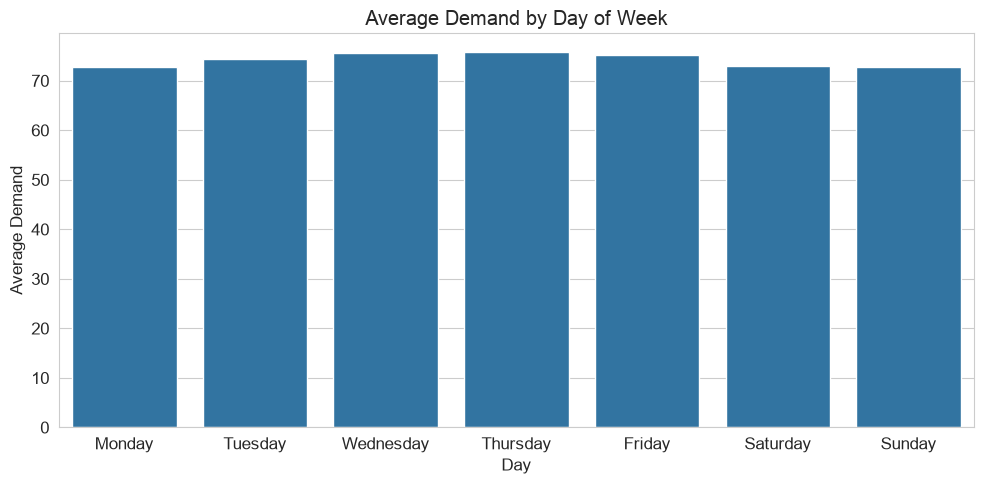

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=weekday_demand.index,
    y=weekday_demand.values
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Demand")

plt.tight_layout()

plt.savefig("../outputs/figures/weekday_demand.png")

plt.show()

In [59]:
demand_df["month"] = demand_df["date"].dt.month_name()

In [60]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_avg = (
    demand_df
    .groupby("month")["demand"]
    .mean()
    .reindex(month_order)
)

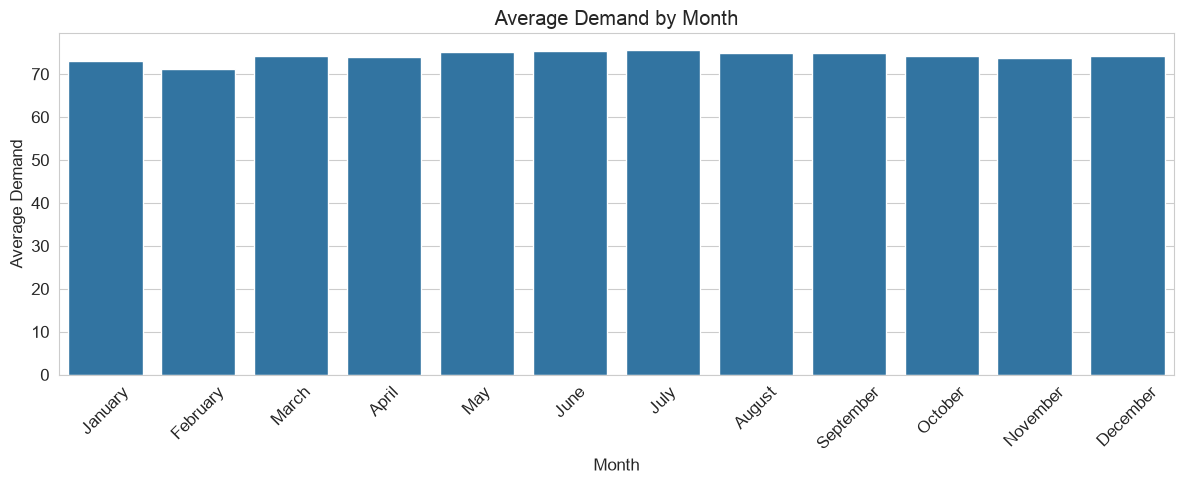

In [61]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_avg.index,
    y=monthly_avg.values
)

plt.xticks(rotation=45)

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Demand")

plt.tight_layout()

plt.savefig("../outputs/figures/monthly_seasonality.png")

plt.show()

In [62]:
promo = promo_df.copy()

In [63]:
promo.drop(columns=["Unnamed: 0"], inplace=True)

In [64]:
promo["promotion_end"] = (
    promo["promotion_date"]
    + pd.Timedelta(days=6)
)

In [65]:
demand_df["promotion"] = 0

In [66]:
for _, row in promo.iterrows():

    mask = (
        (demand_df["date"] >= row["promotion_date"]) &
        (demand_df["date"] <= row["promotion_end"]) &
        (demand_df["sku"] == row["sku"]) &
        (demand_df["supermarket"] == row["supermarket"])
    )

    demand_df.loc[mask, "promotion"] = 1

In [67]:
promotion_effect = (
    demand_df
    .groupby("promotion")["demand"]
    .mean()
)

promotion_effect

promotion
0    74.165680
1    81.455556
Name: demand, dtype: float64

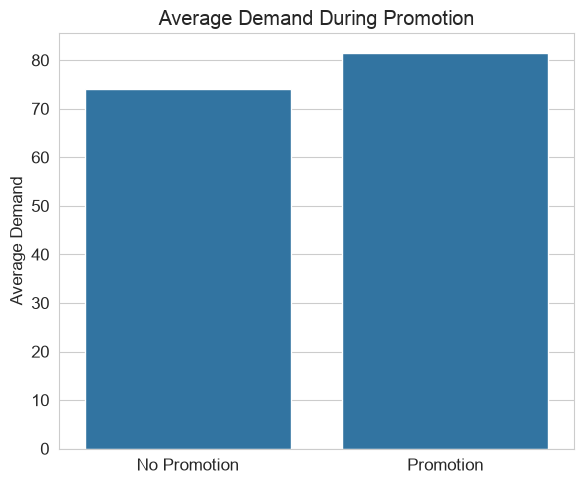

In [68]:
plt.figure(figsize=(6,5))

sns.barplot(
    x=["No Promotion","Promotion"],
    y=promotion_effect.values
)

plt.title("Average Demand During Promotion")

plt.ylabel("Average Demand")

plt.tight_layout()

plt.savefig("../outputs/figures/promotion_effect.png")

plt.show()

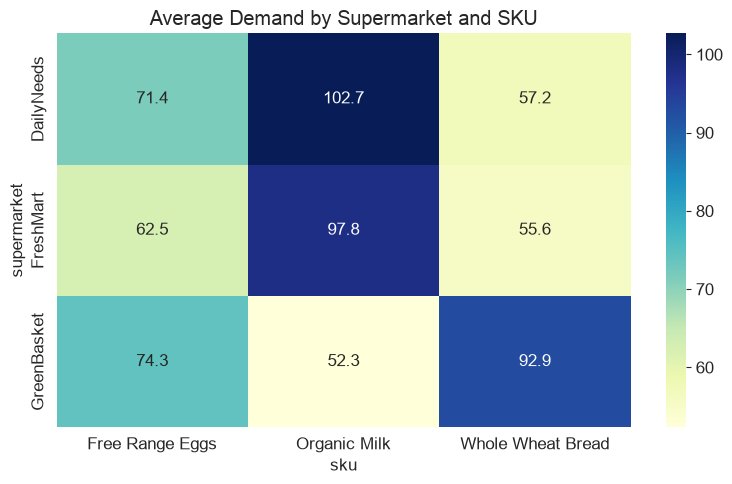

In [69]:
pivot = demand_df.pivot_table(
    values="demand",
    index="supermarket",
    columns="sku",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f"
)

plt.title("Average Demand by Supermarket and SKU")

plt.tight_layout()

plt.savefig("../outputs/figures/demand_heatmap.png")

plt.show()

<Axes: >

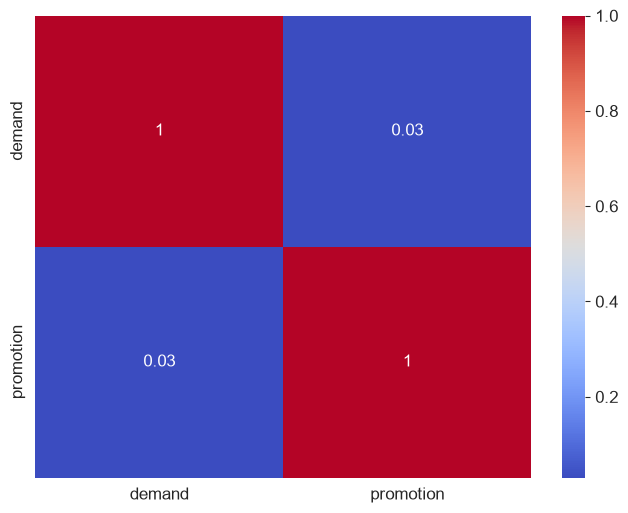

In [70]:
corr = demand_df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm")

{'whiskers': [<matplotlib.lines.Line2D at 0x130550f80>,
 'caps': [<matplotlib.lines.Line2D at 0x130551250>,
 'boxes': [<matplotlib.lines.Line2D at 0x13052f980>],
 'medians': [<matplotlib.lines.Line2D at 0x130552ba0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1305502c0>],
 'means': []}

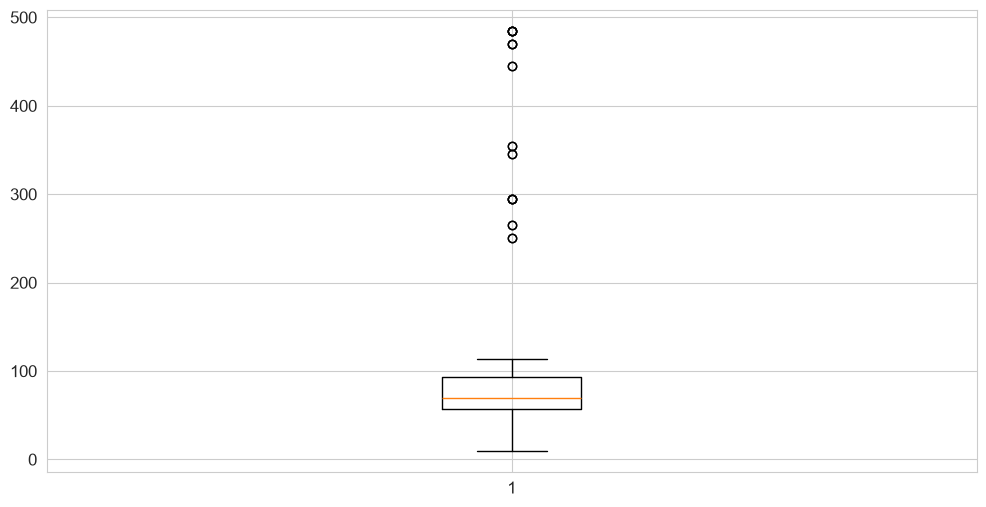

In [71]:
plt.boxplot(demand_df["demand"].dropna())

<Axes: xlabel='sku', ylabel='demand'>

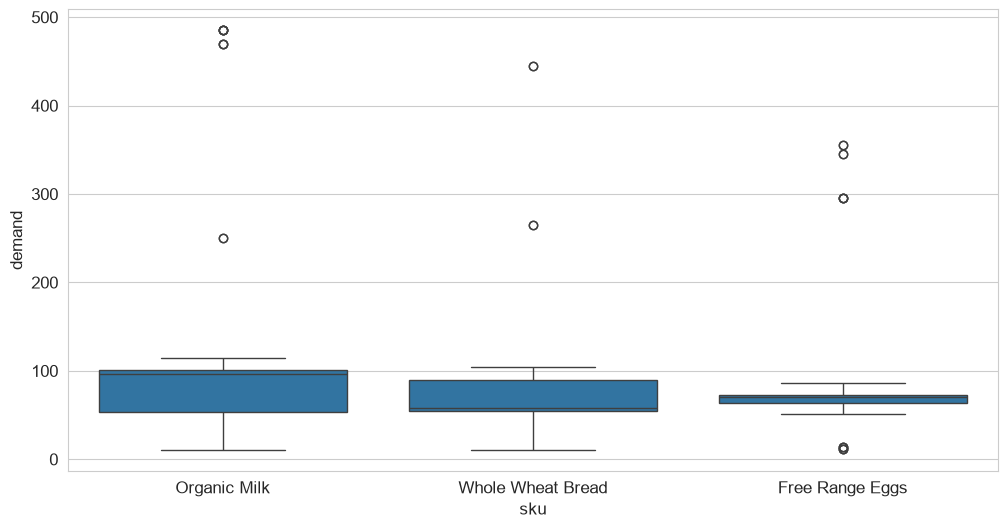

In [72]:
sns.boxplot(
    x="sku",
    y="demand",
    data=demand_df
)

# Exploratory Data Analysis Summary

The objective of this exploratory data analysis was to understand the historical demand data, identify key demand drivers, assess data quality, and discover patterns that would guide feature engineering and model selection for the demand forecasting task.

## Data Quality

* The demand dataset contains 9,855 daily observations across 3 supermarket chains and 3 product SKUs.
* Approximately 11.3% of demand values are missing, while no duplicate records were found.
* Missing values are evenly distributed across supermarkets and SKUs rather than concentrated in specific periods, suggesting that they can be handled using appropriate imputation techniques during preprocessing.



## Demand Distribution

* Most daily demand values fall between 50 and 100 units.
* The demand distribution is slightly right-skewed due to a few high-demand observations.
* Several extreme demand values were identified; however, these occurred repeatedly for specific supermarket-SKU combinations across multiple years, indicating that they are genuine business events rather than erroneous records.



## Demand Trend

* Overall demand exhibits a gradual upward trend throughout the three-year period.
* Daily demand shows significant short-term fluctuations, while the 30-day rolling average reveals steady long-term business growth.
* Monthly average demand also indicates a gradual increase without major structural changes.



## Product-Level Insights

* Organic Milk consistently records the highest demand among all products.
* Whole Wheat Bread demonstrates moderate demand with stable growth.
* Free Range Eggs has the lowest average demand while maintaining a gradual upward trend.

These observations indicate that product type is an important factor influencing demand.



## Supermarket-Level Insights

* DailyNeeds consistently records the highest average demand.
* GreenBasket follows with moderate demand.
* FreshMart has the lowest average demand among the three supermarkets.

This suggests that customer purchasing behavior differs across supermarket chains, making supermarket identity an important predictive feature.



## Seasonality Analysis

Weekly seasonality is relatively weak, with only small differences in demand across weekdays. Similarly, monthly demand remains fairly stable throughout the year, indicating limited annual seasonality.

Although these temporal patterns are not strong, they may still provide useful predictive information and will therefore be included as engineered features.



## Promotion Analysis

Demand during promotional periods is noticeably higher than during non-promotional periods, with an average increase of approximately 9–10%. This confirms that promotions have a measurable impact on customer purchasing behavior and should be incorporated into the forecasting model.


## Key Demand Drivers

Based on the exploratory analysis, the primary factors influencing demand appear to be:

* Historical demand trend
* Product (SKU)
* Supermarket
* Promotional events

## Secondary factors include:

* Day of the week
* Month of the year


## Implications for Feature Engineering

The insights obtained during EDA will guide the next stage of the project. The forecasting model will incorporate both historical and calendar-based information by engineering features such as:

* Lag demand features
* Rolling statistics
* Promotion indicator
* Day of week
* Month
* Product (SKU)
* Supermarket

These features will enable the model to capture long-term trends, temporal patterns, and business-specific demand drivers, leading to more accurate demand forecasts.